        N  p        T      S      E
   100000  1    0.945 1.0000 1.0000
   100000  2    0.781 1.2100 0.6050
   100000  4    0.837 1.1290 0.2823
   100000  8   11.793 0.0801 0.0100
   100000 16   16.135 0.0586 0.0037
   100000 32   22.814 0.0414 0.0013
  1000000  1    6.179 1.0000 1.0000
  1000000  2    5.516 1.1202 0.5601
  1000000  4    6.830 0.9047 0.2262
  1000000  8   59.119 0.1045 0.0131
  1000000 16   69.389 0.0890 0.0056
  1000000 32   68.076 0.0908 0.0028
 10000000  1   70.870 1.0000 1.0000
 10000000  2   52.409 1.3522 0.6761
 10000000  4   45.993 1.5409 0.3852
 10000000  8  559.746 0.1266 0.0158
 10000000 16  627.031 0.1130 0.0071
 10000000 32  597.790 0.1186 0.0037
100000000  1  708.103 1.0000 1.0000
100000000  2  534.486 1.3248 0.6624
100000000  4  450.805 1.5708 0.3927
100000000  8 5445.128 0.1300 0.0163
100000000 16 6337.299 0.1117 0.0070
100000000 32 5883.743 0.1203 0.0038


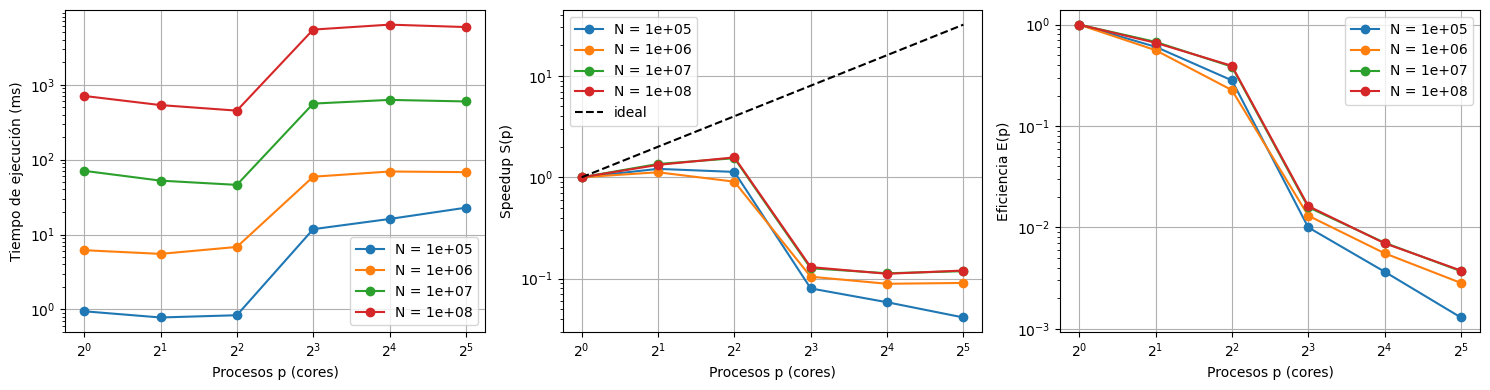

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("tiempos.csv", header=None, names=["tag", "N", "p", "T"])
df["T"] *= 1000                                   # s -> ms
t = df.groupby(["N", "p"])["T"].median().reset_index()
t1 = t[t.p == 1].set_index("N")["T"]
t["S"] = t.apply(lambda r: t1[r["N"]] / r["T"], axis=1)
t["E"] = t["S"] / t["p"]
print(t.round(4).to_string(index=False))          # para comprobar la tabla

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
etiquetas = ["Tiempo de ejecución (ms)", "Speedup S(p)", "Eficiencia E(p)"]
for col, a, lab in zip(["T", "S", "E"], ax, etiquetas):
    for N, g in t.groupby("N"):
        a.plot(g.p, g[col], marker="o", label=f"N = {N:.0e}")
    a.set_xscale("log", base=2)
    a.set_yscale("log")
    a.set_xlabel("Procesos p (cores)")
    a.set_ylabel(lab)
    a.grid(True)
ax[1].plot([1, 32], [1, 32], "k--", label="ideal")
for a in ax:
    a.legend()
plt.tight_layout()
plt.savefig("ej7.png", dpi=150)

In [3]:
datos = """CSV,100000000,16,6.375302
CSV,100000000,16,6.337299
CSV,100000000,16,6.313121
CSV,100000000,1,0.708103
CSV,100000000,1,0.697078
CSV,100000000,1,0.773126
CSV,100000000,2,0.512645
CSV,100000000,2,0.534486
CSV,100000000,2,0.615541
CSV,100000000,32,5.850377
CSV,100000000,32,5.883743
CSV,100000000,32,6.324749
CSV,100000000,4,0.450805
CSV,100000000,4,0.441514
CSV,100000000,4,0.508204
CSV,100000000,8,5.445128
CSV,100000000,8,5.623872
CSV,100000000,8,5.409092
CSV,10000000,16,0.621862
CSV,10000000,16,0.658458
CSV,10000000,16,0.627031
CSV,10000000,1,0.071408
CSV,10000000,1,0.070870
CSV,10000000,1,0.069858
CSV,10000000,2,0.052887
CSV,10000000,2,0.052030
CSV,10000000,2,0.052409
CSV,10000000,32,0.597790
CSV,10000000,32,0.597183
CSV,10000000,32,0.632326
CSV,10000000,4,0.045993
CSV,10000000,4,0.043847
CSV,10000000,4,0.051863
CSV,10000000,8,0.539686
CSV,10000000,8,0.586335
CSV,10000000,8,0.559746
CSV,1000000,16,0.069389
CSV,1000000,16,0.068057
CSV,1000000,16,0.085990
CSV,1000000,1,0.006918
CSV,1000000,1,0.006132
CSV,1000000,1,0.006179
CSV,1000000,2,0.006049
CSV,1000000,2,0.005516
CSV,1000000,2,0.005399
CSV,1000000,32,0.073937
CSV,1000000,32,0.066972
CSV,1000000,32,0.068076
CSV,1000000,4,0.006549
CSV,1000000,4,0.006830
CSV,1000000,4,0.006925
CSV,1000000,8,0.059324
CSV,1000000,8,0.058393
CSV,1000000,8,0.059119
CSV,100000,16,0.016343
CSV,100000,16,0.016135
CSV,100000,16,0.015539
CSV,100000,1,0.000945
CSV,100000,1,0.000866
CSV,100000,1,0.001001
CSV,100000,2,0.000781
CSV,100000,2,0.000769
CSV,100000,2,0.000782
CSV,100000,32,0.022814
CSV,100000,32,0.023236
CSV,100000,32,0.022694
CSV,100000,4,0.000837
CSV,100000,4,0.000840
CSV,100000,4,0.000747
CSV,100000,8,0.012479
CSV,100000,8,0.011793
CSV,100000,8,0.011700
"""
with open("tiempos.csv", "w") as f:
    f.write(datos)